--- VYHODNOCENÍ SIR MODELŮ PRO 5 NEMOCÍ ---

Uchazeč: Sezónní chřipka (R0 = 1.5)
 1. Kdy dojde k vrcholu epidemie? Cca 40.1. den simulace (Maximum: 66 nakažených naráz).
 2. Jak dlouho epidemie potrvá? Aktivní vlna opadne (klesne pod 1 % populace) kolem 79.4. dne.
 3. Kolik jedinců nakonec onemocní? Celkem cca 587 lidí z 1000 (58.7% populace).

Uchazeč: Spalničky (R0 = 12.0)
 1. Kdy dojde k vrcholu epidemie? Cca 7.1. den simulace (Maximum: 710 nakažených naráz).
 2. Jak dlouho epidemie potrvá? Aktivní vlna opadne (klesne pod 1 % populace) kolem 51.1. dne.
 3. Kolik jedinců nakonec onemocní? Celkem cca 1000 lidí z 1000 (100.0% populace).

Uchazeč: Ebola (R0 = 2.0)
 1. Kdy dojde k vrcholu epidemie? Cca 72.0. den simulace (Maximum: 156 nakažených naráz).
 2. Jak dlouho epidemie potrvá? Aktivní vlna opadne (klesne pod 1 % populace) kolem 120.0. dne.
 3. Kolik jedinců nakonec onemocní? Celkem cca 763 lidí z 1000 (76.3% populace).

Uchazeč: Covid-19 (Omic.) (R0 = 3.5)
 1. Kdy dojde k vrcholu

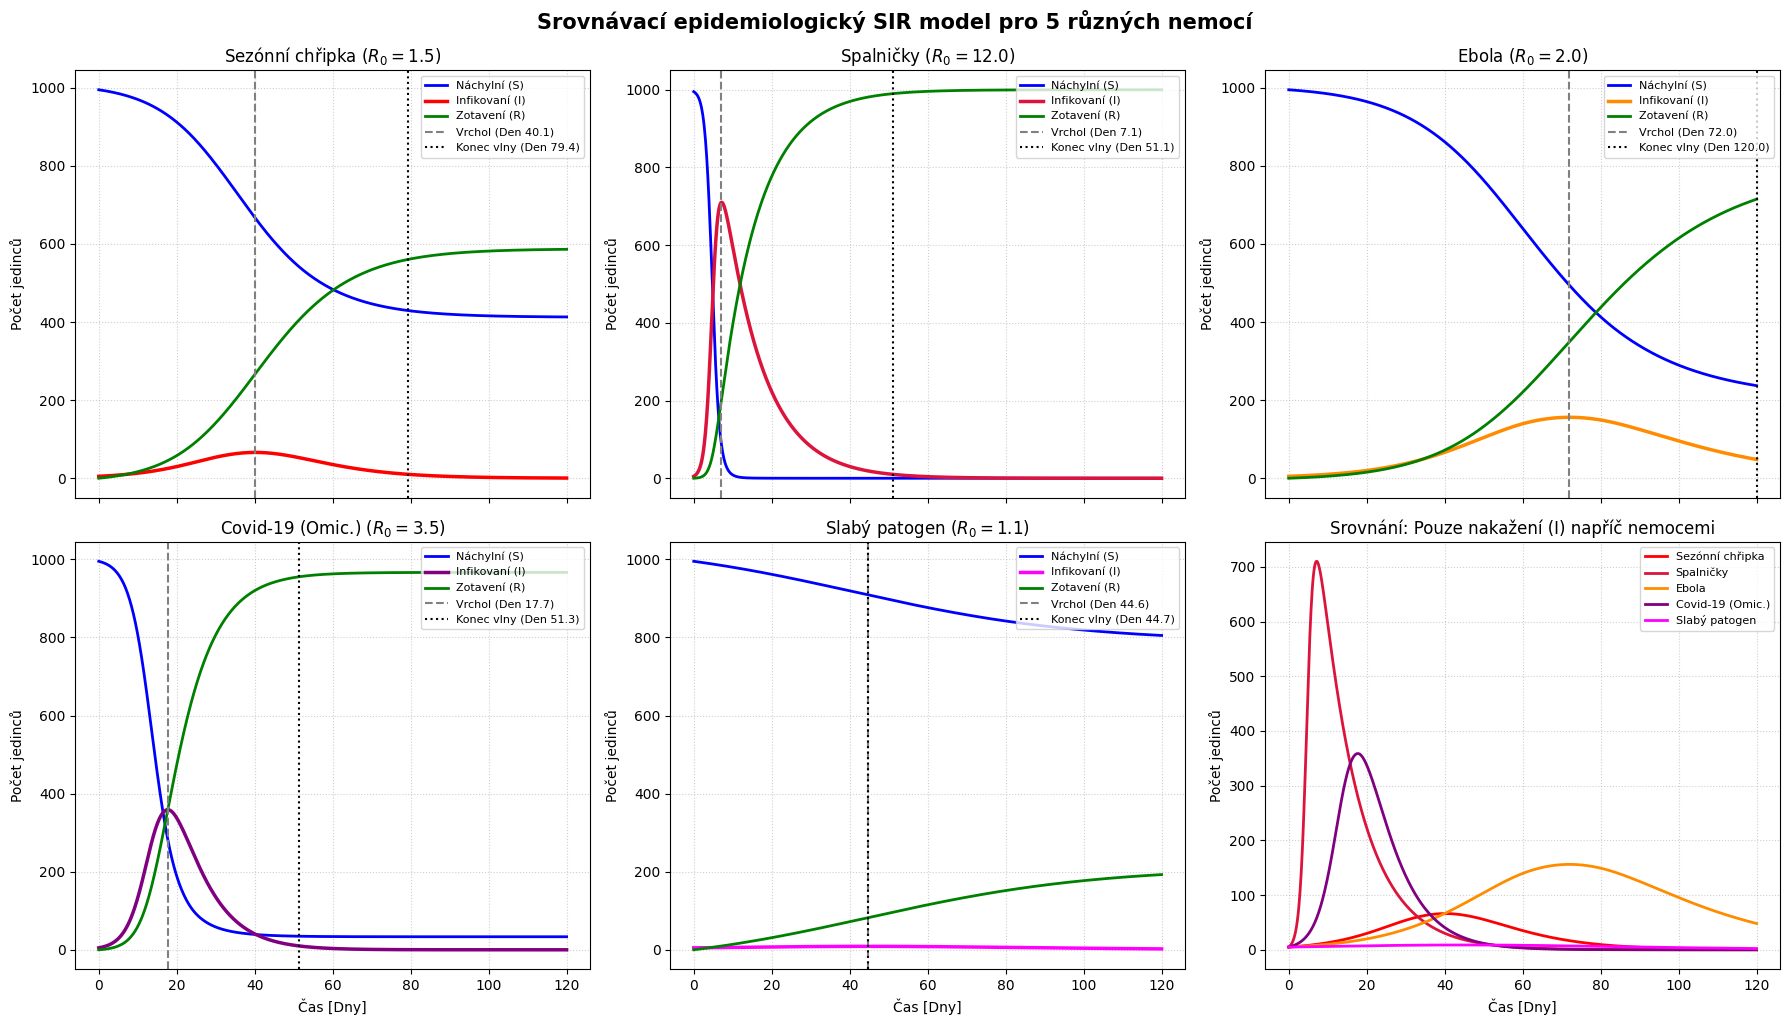

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Definice původní diferenciální rovnice SIR modelu
def sir_model(t, y, N, beta, gamma):
    """
    Klasický SIR model pro jednu konkrétní nemoc.
    S: Náchylní, I: Infikovaní, R: Zotavení
    """
    S, I, R = y
    dSdt = - (beta * S * I) / N
    dIdt = (beta * S * I) / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# --- DEFINICE PARAMETRŮ PRO 5 RŮZNÝCH NEMOCÍ ---
N = 1000      # Celková populace (shodná pro všechny simulace)
I0 = 5        # Počáteční počet nakažených
R0_stat = 0   # Počáteční počet vyléčených
S0 = N - I0 - R0_stat

# Seznam nemocí s jejich typickými vlastnostmi (Doba léčby v dnech, R0)
specifikace_nemoci = [
    {"nazev": "Sezónní chřipka", "doba_lecby": 5.0,  "R0": 1.5, "barva": "red"},
    {"nazev": "Spalničky",       "doba_lecby": 10.0, "R0": 12.0, "barva": "crimson"},
    {"nazev": "Ebola",           "doba_lecby": 14.0, "R0": 2.0, "barva": "darkorange"},
    {"nazev": "Covid-19 (Omic.)", "doba_lecby": 7.0,  "R0": 3.5, "barva": "purple"},
    {"nazev": "Slabý patogen",   "doba_lecby": 4.0,  "R0": 1.1, "barva": "magenta"}
]

t_sir = np.linspace(0, 120, 1200) # Prodlouženo na 120 dní, aby dlouhé nemoci stihly doběhnout

# Příprava grafického okna - mřížka 2x3 (5 sub-grafů pro nemoci, 6. zůstane pro srovnání)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

print("--- VYHODNOCENÍ SIR MODELŮ PRO 5 NEMOCÍ ---")

# Projdeme všech 5 definovaných nemocí, nasimulujeme je a vykreslíme
for idx, nemoc in enumerate(specifikace_nemoci):
    ax = axes[idx]

    # Výpočet beta a gamma parametrů na základě zadané doby léčby a R0
    gamma_sir = 1.0 / nemoc["doba_lecby"]
    beta_sir = nemoc["R0"] * gamma_sir

    # Numerické řešení soustavy diferenciálních rovnic pomocí solve_ivp
    sol_sir = solve_ivp(sir_model, (0, 120), [S0, I0, R0_stat], args=(N, beta_sir, gamma_sir), t_eval=t_sir)

    # Rozbalení výsledků
    S_res, I_res, R_res = sol_sir.y

    # Hledání vrcholu epidemie pro danou nemoc
    max_infected_idx = np.argmax(I_res)
    t_peak = sol_sir.t[max_infected_idx]
    max_infected = I_res[max_infected_idx]
    total_sick = R_res[-1] + I_res[-1]

    # VÝPOČET TRVÁNÍ EPIDEMIE:
    konec_idx = np.where((sol_sir.t > t_peak) & (I_res < (0.01 * N)))[0]
    t_duration = sol_sir.t[konec_idx[0]] if len(konec_idx) > 0 else 120.0

    # --- VYKRESLENÍ GRAFU ---
    ax.plot(sol_sir.t, S_res, label='Náchylní (S)', color='blue', lw=2)
    ax.plot(sol_sir.t, I_res, label=f'Infikovaní (I)', color=nemoc["barva"], lw=2.5)
    ax.plot(sol_sir.t, R_res, label='Zotavení (R)', color='green', lw=2)

    # Přidání svislé čáry označující vrchol epidemie
    ax.axvline(x=t_peak, color='gray', linestyle='--', label=f'Vrchol (Den {t_peak:.1f})')
    # Přidání svislé čáry označující praktický konec epidemie
    ax.axvline(x=t_duration, color='black', linestyle=':', label=f'Konec vlny (Den {t_duration:.1f})')

    # Estetika jednotlivého grafu
    ax.set_title(f"{nemoc['nazev']} ($R_0 = {nemoc['R0']}$)")
    ax.set_ylabel("Počet jedinců")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)

    print(f"\nUchazeč: {nemoc['nazev']} (R0 = {nemoc['R0']})")
    print(f" 1. Kdy dojde k vrcholu epidemie? Cca {t_peak:.1f}. den simulace (Maximum: {max_infected:.0f} nakažených naráz).")
    print(f" 2. Jak dlouho epidemie potrvá? Aktivní vlna opadne (klesne pod 1 % populace) kolem {t_duration:.1f}. dne.")
    print(f" 3. Kolik jedinců nakonec onemocní? Celkem cca {total_sick:.0f} lidí z {N} ({total_sick/N*100:.1f}% populace).")

# Využití 6. pozice v mřížce pro přímé srovnání průběhu nákaz (křivky I)
ax_srovnani = axes[5]
for nemoc in specifikace_nemoci:
    gamma_sir = 1.0 / nemoc["doba_lecby"]
    beta_sir = nemoc["R0"] * gamma_sir
    sol_sir = solve_ivp(sir_model, (0, 120), [S0, I0, R0_stat], args=(N, beta_sir, gamma_sir), t_eval=t_sir)
    ax_srovnani.plot(sol_sir.t, sol_sir.y[1], color=nemoc["barva"], lw=2, label=f"{nemoc['nazev']}")

ax_srovnani.set_title("Srovnání: Pouze nakažení (I) napříč nemocemi")
ax_srovnani.set_ylabel("Počet jedinců")
ax_srovnani.legend(loc="upper right", fontsize=8)
ax_srovnani.grid(True, linestyle=":", alpha=0.6)

# Společné popisky pro spodní řadu grafů
for ax in axes[3:6]:
    ax.set_xlabel("Čas [Dny]")

plt.tight_layout()
plt.suptitle("Srovnávací epidemiologický SIR model pro 5 různých nemocí", fontsize=15, weight='bold', y=1.02)
plt.show()